### 폐암 수술 환자의 생존율 예측 데이타셋 살펴보기

- 폐암 환자 수술 기록 데이터
- 총 470개 관측치, 17개 속성으로 구성
- 설명변수(X) – 16개, 종속변수(클래스, 레이블, Y) – 1개(1:생존, 0:사망)

In [114]:
import tensorflow as tf
import numpy as np

In [115]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

tf.random.set_seed(0)

In [116]:
import pandas as pd

In [117]:
df = pd.read_csv("./data/surgery1.csv", header=None)
df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,1,2.88,2.16,1,0,0,0,1,1,3,0,0,0,1,0,60,0
1,2,3.40,1.88,0,0,0,0,0,0,1,0,0,0,1,0,51,0
2,2,2.76,2.08,1,0,0,0,1,0,0,0,0,0,1,0,59,0
3,2,3.68,3.04,0,0,0,0,0,0,0,0,0,0,0,0,54,0
4,2,2.44,0.96,2,0,1,0,1,1,0,0,0,0,1,0,73,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
465,1,3.88,2.12,1,0,0,0,1,0,2,0,0,0,1,0,63,0
466,2,3.76,3.12,0,0,0,0,0,0,0,0,0,0,1,0,61,0
467,2,3.04,2.08,1,0,0,0,1,0,2,0,0,0,0,0,52,0
468,2,1.96,1.68,1,0,0,0,1,1,1,0,0,0,1,0,79,0


In [118]:
X = df.iloc[:, 0:16]
y = df.iloc[:, 16]


In [119]:
df.rename(columns={16: 'label'}, inplace=True)
df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,label
0,1,2.88,2.16,1,0,0,0,1,1,3,0,0,0,1,0,60,0
1,2,3.40,1.88,0,0,0,0,0,0,1,0,0,0,1,0,51,0
2,2,2.76,2.08,1,0,0,0,1,0,0,0,0,0,1,0,59,0
3,2,3.68,3.04,0,0,0,0,0,0,0,0,0,0,0,0,54,0
4,2,2.44,0.96,2,0,1,0,1,1,0,0,0,0,1,0,73,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
465,1,3.88,2.12,1,0,0,0,1,0,2,0,0,0,1,0,63,0
466,2,3.76,3.12,0,0,0,0,0,0,0,0,0,0,1,0,61,0
467,2,3.04,2.08,1,0,0,0,1,0,2,0,0,0,0,0,52,0
468,2,1.96,1.68,1,0,0,0,1,1,1,0,0,0,1,0,79,0


In [120]:
df['label'].value_counts()

label
0    400
1     70
Name: count, dtype: int64

<Axes: xlabel='label'>

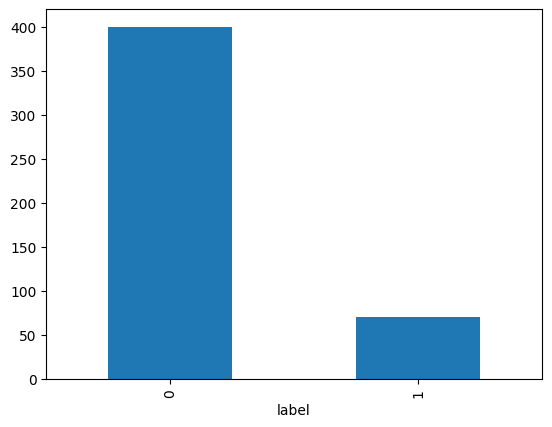

In [121]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')

### 3. 딥러닝 모델 정의
- 1) 입력층 : 입력변수가 16개, input_dim = 16 또는 input_shape = (16, )로 설정
- 2) 은닉층 : 30개의 노드, 활성화 함수는 relu로 설정
- 3) 출력층 
    - 출력 값이 1개, Dense의 노드 수를 1으로 설정
    - 출력층의 활성화 함수 : 이항 분류이므로 활성화함수를 sigmoid로 사용

In [122]:
model = Sequential()
model.add(Dense(30, input_dim=16,activation='relu'))
model.add(Dense(1, activation='sigmoid'))

c:\lys\03python\02code\01test\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [123]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 30)             │           510 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 541 (2.11 KB)

 Trainable params: 541 (2.11 KB)

 Non-trainable params: 0 (0.00 B)

In [124]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['acc']
    )

In [134]:
history = model.fit(X, y, epochs = 50, batch_size=16)

Epoch 1/50


30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.8532 - loss: 0.3881 
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8553 - loss: 0.3879
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8532 - loss: 0.3880 
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.8553 - loss: 0.3878
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8553 - loss: 0.3877 
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8553 - loss: 0.3877  
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8574 - loss: 0.3876
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8574 - loss: 0.3874 
Epoch 9/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8553 - loss: 0.3877  
Epoch 10/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8574 - loss: 0.3873
Epoch 11/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8532 - loss: 0.3875
Epoch 12/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8574 - loss: 0.3871 
Epoch 13/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

In [135]:
model.evaluate(X, y)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8489 - loss: 0.3826 


[0.382607102394104, 0.848936140537262]

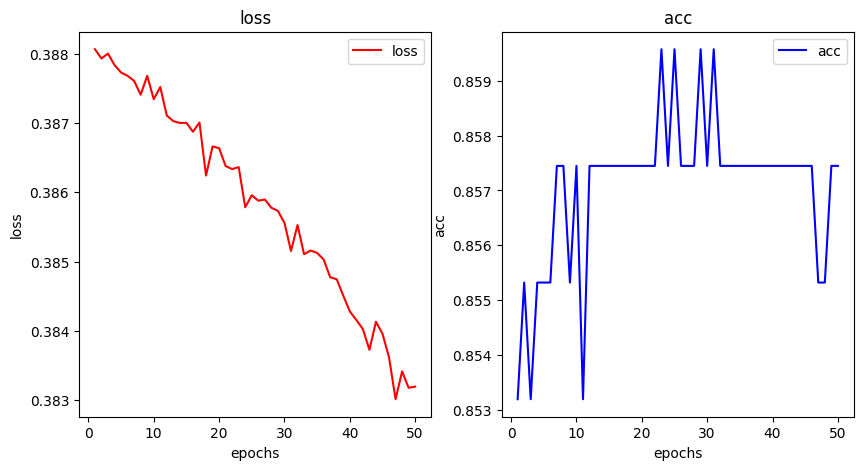

In [136]:
his_dict = history.history
# his_dict
loss = his_dict['loss']
acc = his_dict['acc']

epochs = range(1,len(loss)+1)
fig = plt.figure(figsize=(10,5))

# loss 그래프
ax1 = fig.add_subplot(1,2,1)
ax1.plot(epochs,loss,color="red",label='loss')
ax1.set_title('loss')
ax1.set_xlabel('epochs')
ax1.set_ylabel('loss')
ax1.legend()

# acc 그래프
ax2 = fig.add_subplot(1,2,2)
ax2.plot(epochs,acc,color="blue",label='acc')
ax2.set_title('acc')
ax2.set_xlabel('epochs')
ax2.set_ylabel('acc')
ax2.legend()


plt.show()

In [128]:
X[0:1]

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,1,2.88,2.16,1,0,0,0,1,1,3,0,0,0,1,0,60


In [129]:
y[0:1]

0    0
Name: 16, dtype: int64

In [130]:
model.predict(X[0:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


array([[0.38073462]], dtype=float32)